In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, year, month, to_date
import matplotlib.pyplot as plt
import os

In [ ]:
def load_file(spark, path):
    """Read file CSV to DataFrame"""
    df = spark.read.csv(path, header=True, inferSchema=True)
    return df

In [ ]:
def plot_chart(x, y, title, xlabel, ylabel, save_path, chart_type="bar"):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.figure(figsize=(12, 6))

    if chart_type == "bar":
        plt.bar(x, y, color="lightblue")
    elif chart_type == "line":
        plt.plot(x, y, marker="o", color="orange")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [4]:
def f1_df(df):
    result = df.groupBy("itemDescription") \
               .agg(count("*").alias("purchase_count")) \
               .orderBy(col("purchase_count").desc()) \
               .limit(100)

    pdf = result.toPandas()
    plot_chart(
        pdf["itemDescription"], pdf["purchase_count"],
        "Top 100 Most Purchased Products",
        "Product Name", "Purchase Count", "output_df/f1_top100.png"
    )
    return result

In [5]:
def f2_df(df):
    baskets = df.select("Member_number", "Date").distinct()
    result = baskets.groupBy("Member_number") \
                    .agg(count("*").alias("basket_count")) \
                    .orderBy(col("basket_count").desc()) \
                    .limit(100)

    pdf = result.toPandas()
    plot_chart(
        pdf["Member_number"].astype(str), pdf["basket_count"],
        "Top 100 Customers with Most Baskets",
        "Customer ID", "Number of Baskets", "output_df/f2_top100.png"
    )
    return result

In [6]:
def f3_df(df, product_name):
    df = df.withColumn("Date", to_date(col("Date"), "dd/MM/yyyy"))
    filtered = df.filter(col("itemDescription") == product_name)
    result = filtered.groupBy(
        year("Date").alias("year"),
        month("Date").alias("month")
    ).agg(count("*").alias("purchase_count")) \
     .orderBy(["year", "month"])

    pdf = result.toPandas()
    pdf["year_month"] = pdf["year"].astype(str) + "-" + pdf["month"].astype(str)
    plot_chart(
        pdf["year_month"], pdf["purchase_count"],
        f"Monthly Purchases Trend for '{product_name}'",
        "Month", "Number of Purchases", "output_df/f3_product_trend.png", chart_type="line"
    )
    return result

In [7]:
def f4_df(df, customer_id):
    df = df.withColumn("Date", to_date(col("Date"), "dd/MM/yyyy"))
    baskets = df.select("Member_number", "Date").distinct()
    filtered = baskets.filter(col("Member_number") == customer_id)

    result = filtered.groupBy(
        year("Date").alias("year"),
        month("Date").alias("month")
    ).agg(count("*").alias("basket_count")) \
     .orderBy(["year", "month"])

    pdf = result.toPandas()
    pdf["year_month"] = pdf["year"].astype(str) + "-" + pdf["month"].astype(str)
    plot_chart(
        pdf["year_month"], pdf["basket_count"],
        f"Monthly Basket Count for Customer {customer_id}",
        "Month", "Number of Baskets", "output_df/f4_customer_trend.png", chart_type="line"
    )
    return result

In [8]:
def main():
    spark = SparkSession.builder \
        .appName("Baskets DataFrame Analysis") \
        .master("local[*]") \
        .getOrCreate()

    path = "baskets.csv"  # Change path if needed
    print("📂 Loading CSV file using DataFrame...")
    df = load_file(spark, path)

    print("\n🏆 Running f1_df: Top 100 Most Purchased Products")
    f1_df(df)

    print("\n👥 Running f2_df: Top 100 Customers with Most Baskets")
    f2_df(df)

    print("\n☕ Running f3_df: Monthly Purchases Trend for Product 'coffee'")
    f3_df(df, "coffee")

    print("\n🛒 Running f4_df: Monthly Basket Count for Customer 1249")
    f4_df(df, 1249)

    spark.stop()

📂 Loading CSV file using DataFrame...

🏆 Running f1_df: Top 100 Most Purchased Products


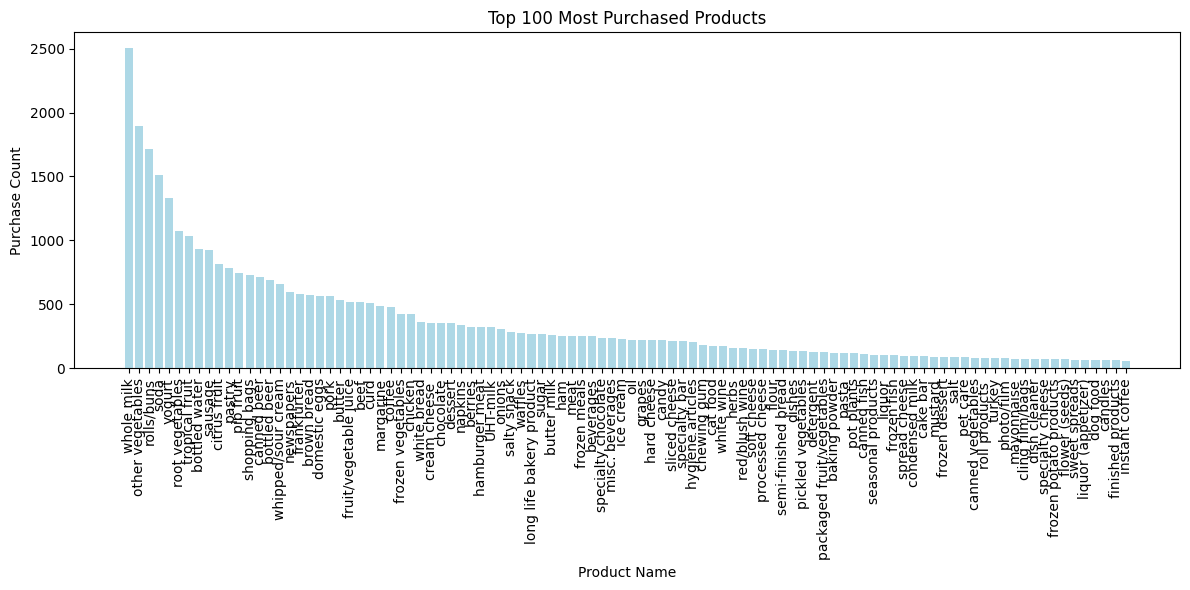


👥 Running f2_df: Top 100 Customers with Most Baskets


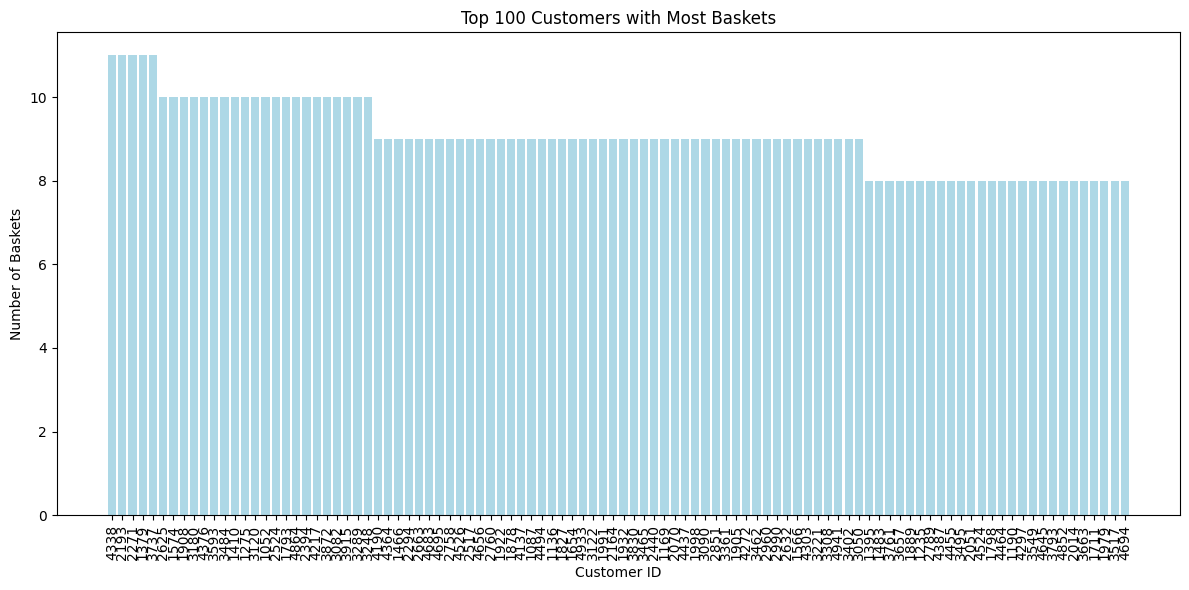


☕ Running f3_df: Monthly Purchases Trend for Product 'coffee'


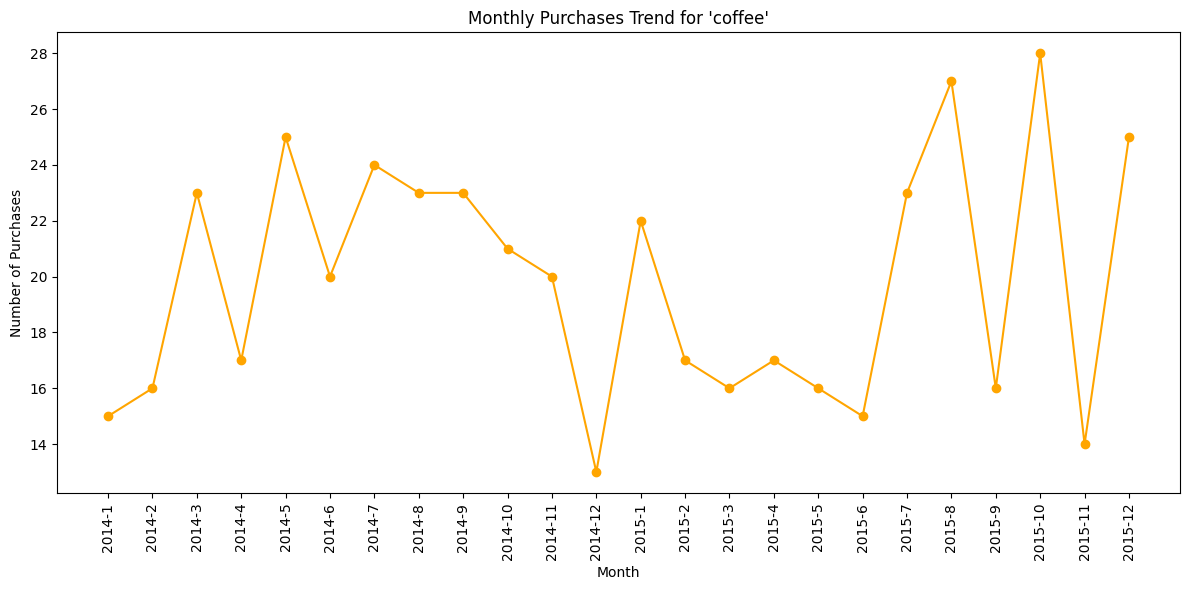


🛒 Running f4_df: Monthly Basket Count for Customer 1249


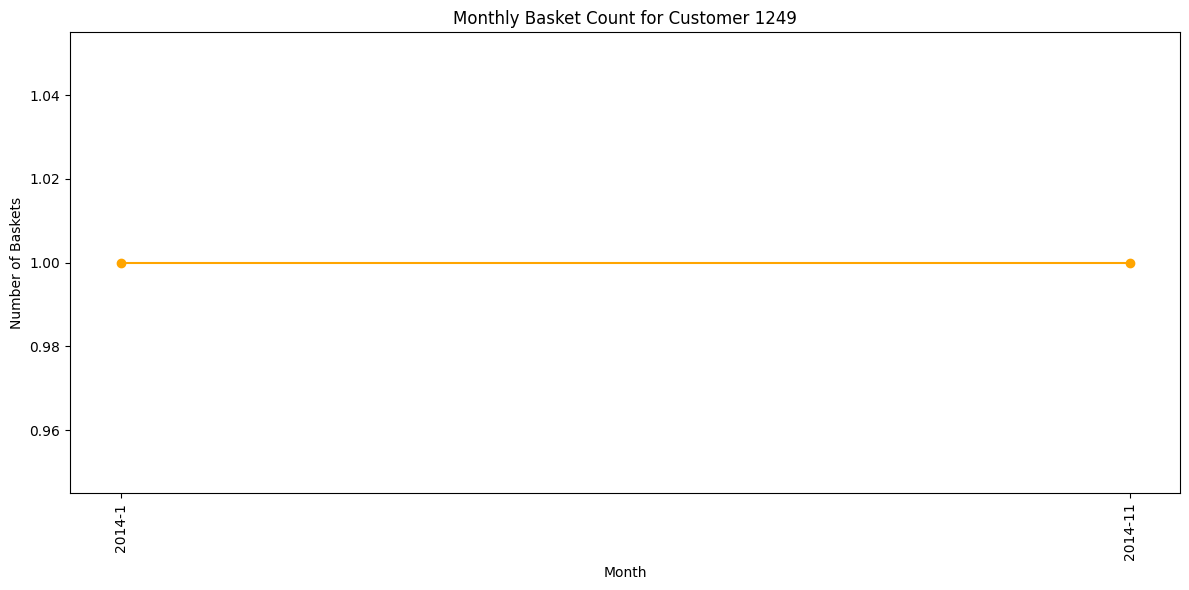

In [9]:
if __name__ == "__main__":
    main()